<hr style="height:10px"> 
 
<div class='container2'>
		<div>
			<img src='img_livro.png' ALIGN='left' style='width:10em'>
		</div>	
	<div style='padding: 0 7em 2em 12em;'>
	<h1>Inteligência Artificial: Uma Abordagem de Aprendizado de Máquina</h1>
    <h3> <a href="http://lattes.cnpq.br/4451540730749377">Katti Faceli</a> &#x25CF; <a href="http://lattes.cnpq.br/3451628262694747">Ana Carolina Lorena</a> &#x25CF; <a href="https://scholar.google.com/citations?user=jjoTZfoAAAAJ&hl=en">João Gama</a> &#x25CF; <a href="http://lattes.cnpq.br/5368680512020633">Tiago Agostinho de Almeida</a> &#x25CF; <a href="http://lattes.cnpq.br/9674541381385819">André C. P. L. F. de Carvalho</a></h3><br>
	<div style="font-size:12pt;float:left;"><b>ISBN:</b> 978-85-216-3920-6 | <b>Edição:</b> 3/2025 | <b>Editora:</b> LTC </div><br><br>
    <div style="font-size:12pt;float:left;"><b>Copyright &copy; 2025 LTC Editora. Todos os direitos reservados.</b></div>
	</div>
</div>



 <hr style="height:5px"> 

    
<h2>Árvores de decisão</h2>

Notebook desenvolvido por: <a href="http://lattes.cnpq.br/2532893661927339">Renato Moraes Silva</a> e <a href="http://lattes.cnpq.br/4012668928932051">Pedro Reis Pires</a>  

 <hr style="height:2px"> 


## Introdução

Árvores de Decisão são uma das abordagens mais populares do aprendizado supervisionado, podendo ser aplicadas tanto em problemas de classificação quanto de regressão [1]. Uma de suas maiores vantagens é funcionar de maneira intuitiva, dividindo o espaço dos dados com bases em regras de decisão simples. Em seu formato mais básico, o método opera através da construção de uma árvore com nós definidos incrementalmente, observando os atributos mais relevantes do conjunto de dados. Ao término do treinamento, cada folha da árvore representa um decisão final de classe ou um valor previsto.

A construção de uma árvore de decisão envolve encontrar os pontos de divisão que melhor separam os dados de acordo com um critério de impureza, como a entropia ou o índice de Gini. Por serem altamente interpretáveis &mdash; visto que cada nó possui uma regra de corte de fácil entendimento &mdash; as árvores de decisão são ideais para aplicações em que a explicabilidade é essencial. No entanto, elas também podem se tornar propensas ao problema de _overfitting_, especialmente quando muito profundas, o que pode afetar sua capacidade de generalização.

Neste notebook, iremos usar árvore de decisão para classificar os dados da base de dados **Seeds** [2] que está na pasta `datasets`. Essa base de dados também pode ser encontrada no seguinte link: <https://archive.ics.uci.edu/ml/datasets/seeds>. Ela contém três variedades de trigo: Kama, Rosa e Canadense. Essas três variedades são representadas pelos seguintes atributos: área, perímetro, compacidade, comprimento do grão, largura do grão, coeficiente de assimetria e comprimento do sulco do grão.

Este *notebook* se refere ao Capítulo **6 (Métodos Simbólicos)**.

---
## Recursos Necessários

Para este *notebook*, deve ser utilizado o `Python 3.5` ou superior com as seguintes bibliotecas externas, que deverão ser instaladas:

* [`matplotlib`](https://matplotlib.org/) (versão 3.1.3 ou superior): construção e exibição de gráficos variados
* [`seaborn`](https://seaborn.pydata.org/) (versão 0.10.0 ou superior): construção e exibição de gráficos variados
* [`numpy`](https://numpy.org) (versão 1.16.2 ou superior): manipulação de dados em formato de vetores e matrizes
* [`pandas`](https://pandas.pydata.org/pandas-docs/stable/index.html) (versão 0.24.1 ou superior): manipulação de dados em formato de tabelas
* [`sklearn`](https://scikit-learn.org/stable/) (versão 1.0.2 ou superior): execução da versão otimizada do KNN

Será utilizado também o conjuntos de dados disponibilizado junto com este *notebook*, que se encontra no diretório `datasets`, em formato de arquivo `.csv`.

---
## Visualizando as amostras da base de dados

Primeiro, iremos importar todas as bibliotecas que serão usadas ao longo deste notebook.

In [1]:
# -*- coding: utf-8 -*-

import numpy as np # importa a biblioteca usada para trabalhar com vetores e matrizes
import pandas as pd # importa a biblioteca usada para trabalhar com dataframes
import sklearn as skl # importa a biblioteca sckit-learn, utilizada para diversas tarefas de AM

from sklearn.tree import plot_tree # Visualizar árvores
from sklearn.metrics import classification_report # Métricas de aprendizado

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, mean_squared_error
from sklearn.inspection import DecisionBoundaryDisplay

# importa bibliotecas de geração de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas carregadas com sucesso!")

Bibliotecas importadas com sucesso!


Ao trabalhar com um problema de aprendizado de máquina, uma análise exploratória junto com a visualização dos dados pode auxiliar na interpretação dos mesmos e como eles estão distribuídos. Primeiro, vamos então carregar os dados do arquivo. 

Obs.: é importante notar que, ao contrário de outros conjuntos de dados utilizados até então, o arquivo original da base de dados não possui título para suas colunas e, por isso, na função `read_csv` do pandas definiremos o parâmetro `header = None`. Adicionalmente, a separação das colunas no arquivo original é feito por espaços em branco de tamanhos variados e, por isso, usaremos como token de separação `sep = '\s+'`.

In [2]:
#importa o arquivo e guarda em um dataframe do Pandas
df_dataset = pd.read_csv( 'datasets/seeds_dataset.txt', sep='\\s+', header=None, index_col=None) 

print('Dados carregados com sucesso!')

Dados carregados com sucesso!


Agora, vamos dar uma olhada nas 5 primeiras amostras da base de dados.

In [3]:
# vamos usar a função display para imprimir o dataframe
display(df_dataset.head(n=6))

,0,1,2,3,4,5,6,7
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
5,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,1


Para facilitar a visualização, vamos nomear as colunas da base de dados com os nomes dos atributos. Depois, vamos substituir o valor das classes pelo nome da variedade de trigo que ela representa: 1 (Kama), 2 (Rosa) ou 3 (Canadense).

In [4]:
df_dataset.columns = ['area','perimetro','compacidade','compr.Grao','larg.Grao','coef.Assimetria', 'compr.SulcoGrao', 'classe']

# converte as classes para string
df_dataset['classe'] = df_dataset['classe'].astype(str)

# troca o valor das classe pelo nome da variedade de trigo que ela representa
df_dataset["classe"] = df_dataset["classe"].replace({'1': 'Kama', '2': 'Rosa', '3': 'Canadense'})

# imprime o dataframe. 
display(df_dataset.head(6))

,area,perimetro,compacidade,compr.Grao,larg.Grao,coef.Assimetria,compr.SulcoGrao,classe
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,Kama
5,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,Kama


Por termos mais de dois atributos, não é possível visualizar as amostras em um único gráfico. Vamos gerar então gráficos de dispersão sobre cada combinação de atributos para visualizarmos como os dados se comportam.

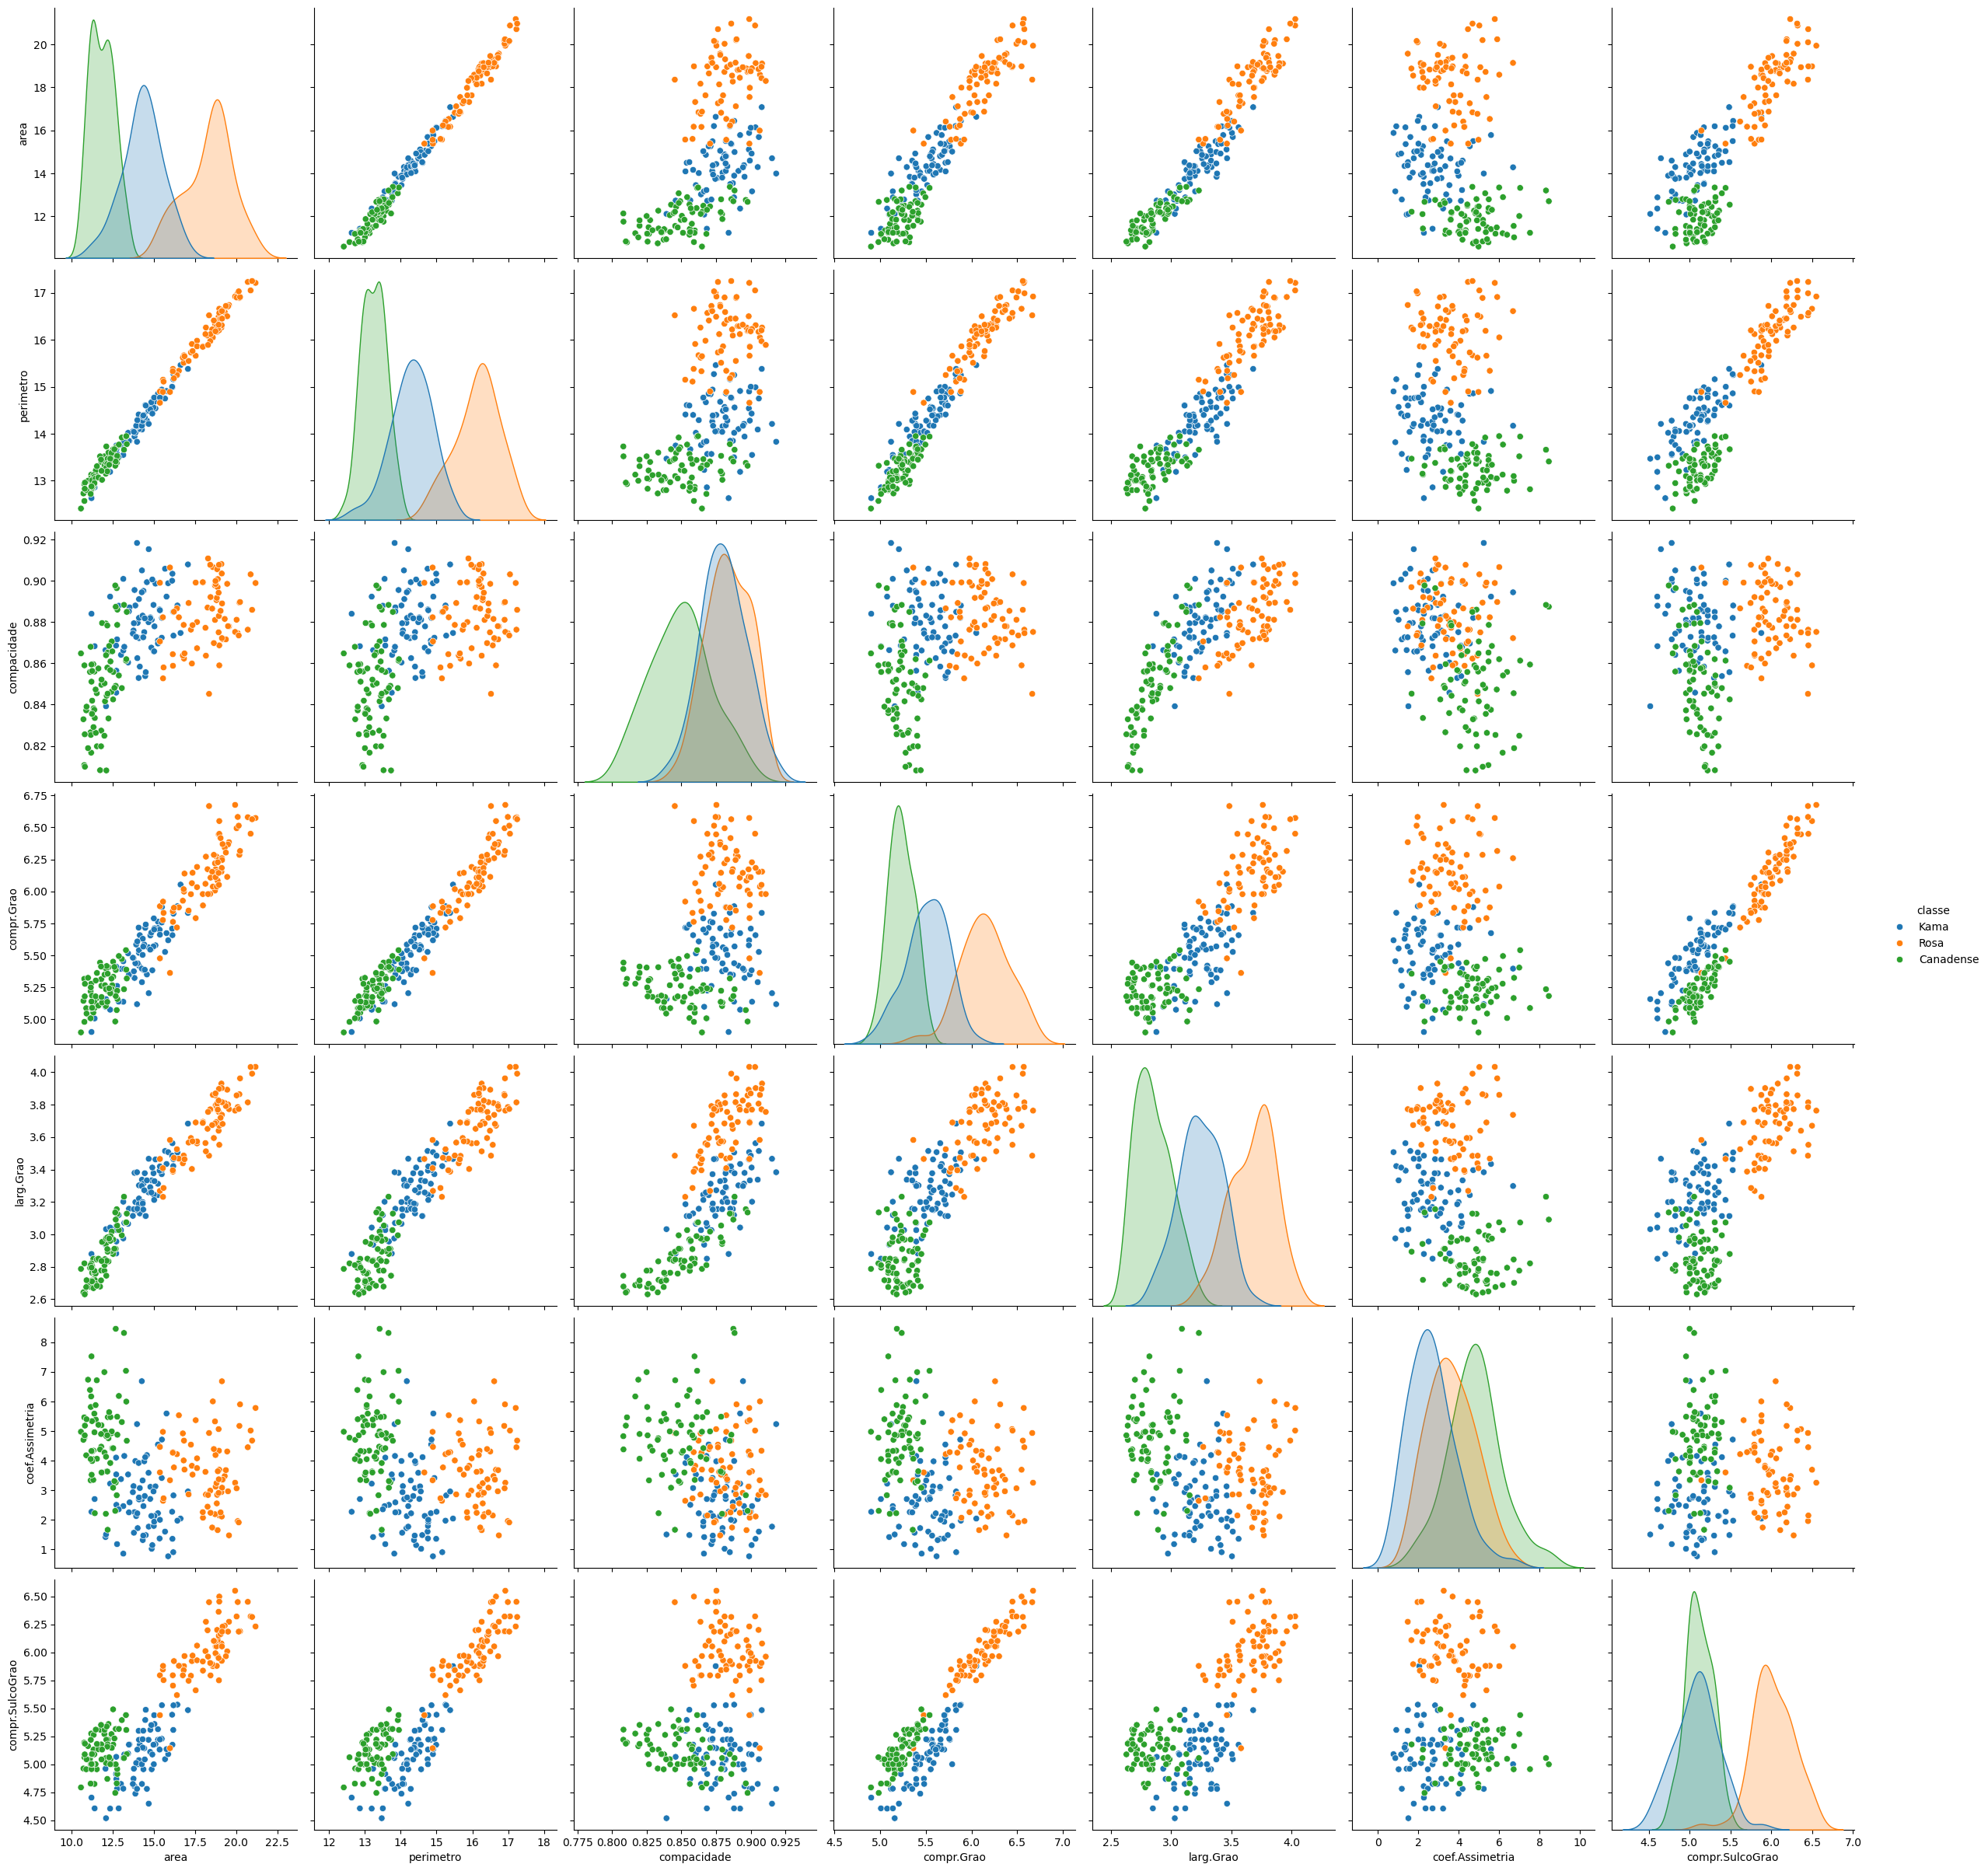

In [5]:
# matriz de gráficos scatter 
sns.pairplot(df_dataset, hue='classe', height=3.5);

# mostra os gráficos usando a função show() da matplotlib
plt.show()

Vamos analisar as principais estatísticas sobre os atributos da base de dados.

In [6]:
# apresenta as principais estatísticas sobre a base de dados
df_detalhes = df_dataset.describe()

display(df_detalhes)

,area,perimetro,compacidade,compr.Grao,larg.Grao,coef.Assimetria,compr.SulcoGrao
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000


Pode-se notar pelas informações mostradas acima que a escala dos valores de alguns atributos é bastante diferente. Por exemplo, o valor médio do atributo *área* é 14.8, enquanto o valor médio do atributo *compacidade* é apenas 0.87. 

Alguns métodos de classificação, como aqueles baseados em distância, são fortemente sensíveis a diferenças na escala dos dados. Neste caso, seria necessário realizar técnicas de normalização sobre as amostras. No entanto, uma das vantagens das Árvores de Decisão e métodos derivados é não ser influenciados por essa particularidade. Por funcionar através de cortes nos dados, o método consegue se adaptar para atributos de diferentes escalas e magnitudes. Desta forma, a normalização não se faz necessária.

Vamos então analisar a distribuição das classes...

classe
Kama         70
Rosa         70
Canadense    70
Name: count, dtype: int64

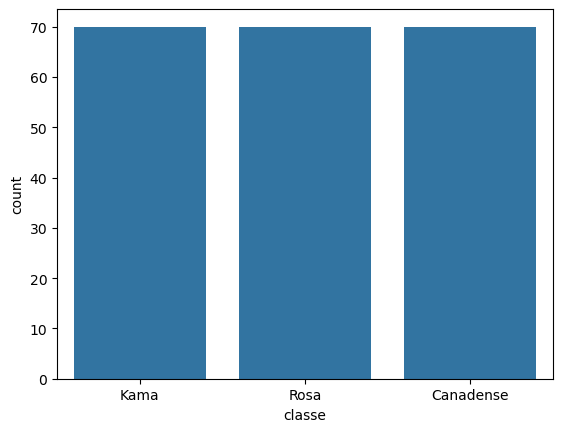

In [7]:
display( df_dataset['classe'].value_counts() )

# cria um gráfico de barras com a frequência de cada classe
sns.countplot(x="classe", data=df_dataset)

# plota o gráfico
plt.show()

Como visto, a base é perfeitamente balanceada, com o mesmo número de amostras para cada uma das 3 classes. Caso contrário, poderíamos ter que aplicar técnicas de redução ou adição de amostras (_under_ ou _oversampling_), para que o método não enfrentasse problemas de generalização.

Podemos então guardar os dados dentro de uma matriz e as classes dentro de um vetor, facilitando a manipulação de dados nos algoritmos aplicados.

In [8]:
# pega os valores das n-1 primeiras colunas e guarda em uma matrix X
X = df_dataset.iloc[:, 0:-1].values  

# pega os valores da última coluna e guarda em um vetor Y
Y = df_dataset.iloc[:, -1].values  

# imprime as 5 primeiras linhas da matriz X
display('X:', X[0:5,:]) 

# imprime os 5 primeiros valores de Y
print('Y:', Y[0:5]) 

'X:'

array([[15.26  , 14.84  ,  0.871 ,  5.763 ,  3.312 ,  2.221 ,  5.22  ],
       [14.88  , 14.57  ,  0.8811,  5.554 ,  3.333 ,  1.018 ,  4.956 ],
       [14.29  , 14.09  ,  0.905 ,  5.291 ,  3.337 ,  2.699 ,  4.825 ],
       [13.84  , 13.94  ,  0.8955,  5.324 ,  3.379 ,  2.259 ,  4.805 ],
       [16.14  , 14.99  ,  0.9034,  5.658 ,  3.562 ,  1.355 ,  5.175 ]])

Y: ['Kama' 'Kama' 'Kama' 'Kama' 'Kama']


---
## Treinando a árvore de decisão

Vamos agora separar a nossa base de dados para realizar o treinamento e avaliação do modelo. Para isso, vamos utilizar validação cruzada $k$-fold.

A validação cruzada $k$-fold é considerada mais robusta que a validação por *holdout*, pois ela garante que o algoritmo será avaliado com todas as amostras da base de dados. Aqui, usaremos ela estratificada, *i.e.*, cada partição deve conter aproximadamente a mesma distribuição original de dados de cada classe. 

Iremos dividir a base em $k=5$ partições. Como temos três classes, cada uma correspondendo a 70 amostras, iremos compôr cada partição por 42 amostras,  com 14 amostras de cada classe. Durante o treinamento e avaliação do modelo, em cada rodada $k$, os dados da $k$-ésima partição irão compôr os dados de teste, enquanto os dados das outras partições representarão os dados de treinamento. É importante que as $k$ partições sejam geradas de forma aleatória, mas para que toda a execução gere o mesmo resultado, vamos usar uma semente para a função de geração de números aleatórios. 

In [9]:
# separa as partições
cv = StratifiedKFold(
    n_splits = 5,
    shuffle=True,
    random_state=10
)

# cria conjuntos de treino e teste
for i, (idxTrain, idxTest) in enumerate(cv.split(X,Y)):
    print('\nFold: ', i)
    
    totalDados = len(idxTrain)+len(idxTest)
    
    print('Qtd. train: %d (%1.2f)' %(
         len(idxTrain), 
         len(idxTrain)/totalDados))
    
    print('Qtd. teste: %d (%1.2f)' %(
         len(idxTest), 
         len(idxTest)/totalDados))


Fold:  0
Qtd. train: 168 (0.80)
Qtd. teste: 42 (0.20)

Fold:  1
Qtd. train: 168 (0.80)
Qtd. teste: 42 (0.20)

Fold:  2
Qtd. train: 168 (0.80)
Qtd. teste: 42 (0.20)

Fold:  3
Qtd. train: 168 (0.80)
Qtd. teste: 42 (0.20)

Fold:  4
Qtd. train: 168 (0.80)
Qtd. teste: 42 (0.20)


Em seguida, podemos criar o nosso modelo de Árvore de Decisão. Para isso, iremos empregar o modelo [DecisionTreeClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.tree.DecisionTreeClassifier.html) da biblioteca _scikit-learn_, que contém uma Árvore de Decisão tradicional, com vários parâmetros diferentes que podem ser configurados, como:
* `criterion`: o critério usado para selecionar os atributos e gerar os cortes, como índice Gini ou entropia;
* `max_depth`: a altura máxima da árvore;
* `min_samples_leaf`: o número mínimo de amostras necessário para se criar uma folha;
* `max_leaf_nodes`: o número máximo de folhas;
* entre outros...

Neste notebook, iremos criar uma árvore de decisão básica que gera cortes através do índice Gini. Para os demais parâmetros, usaremos os valores padrão da biblioteca. Isso pode ser feito de forma fácil da seguinte maneira:

In [10]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
      criterion='gini',
      random_state=10 
)

print(model)

DecisionTreeClassifier(random_state=10)


Agora iremos treinar e avaliar nosso modelo sobre as $k$ partições geradas anteriormente. A cada rodada, usaremos uma partição como teste e cacularemos as métricas de **Precisão**, **Revocação**, **F-Medida** e **Acurácia**.

In [11]:
# dicionário para média das métricas entre os folds
metrics_avg = {} 
metrics_avg['precision'] = 0.0
metrics_avg['recall'] = 0.0
metrics_avg['f1'] = 0.0
metrics_avg['accuracy'] = 0.0

trees = []

for i, (idxTrain, idxTest) in enumerate(cv.split(X,Y)):
    print('\nFold: ', i)
    
    X_train = X[idxTrain,:] # X do treino
    Y_train = Y[idxTrain] # Y do treino
    
    X_test = X[idxTest,:] # X do teste
    Y_test = Y[idxTest] # Y do teste

    # inicializa um novo modelo
    model = DecisionTreeClassifier(
          criterion='gini',
          random_state=10 
    )

    # salva novo modelo
    trees.append(model)

    # treina o modelo sobre as partições de treino
    model.fit(X_train, Y_train)

    # gera a predição sobre a partição de teste
    Y_pred = model.predict(X_test)

    # cálcula e salva as métricas
    metrics = classification_report(Y_test, Y_pred)
    print(metrics)
    
    dictMetrics = classification_report(Y_test, Y_pred, output_dict = True)
    metrics_avg['precision'] += dictMetrics['macro avg']['precision']
    metrics_avg['recall'] += dictMetrics['macro avg']['recall']
    metrics_avg['f1'] += dictMetrics['macro avg']['f1-score']
    metrics_avg['accuracy'] += dictMetrics['accuracy']


# calcula as métricas finais, através da média entre folds
qtdFolds = cv.n_splits
metrics_avg['precision'] = metrics_avg['precision'] / qtdFolds
metrics_avg['recall'] = metrics_avg['recall'] / qtdFolds
metrics_avg['f1'] = metrics_avg['f1'] / qtdFolds
metrics_avg['accuracy'] = metrics_avg['accuracy'] / qtdFolds

print("\n\nMédias das métricas")
print("Precisão: %1.4f" %(metrics_avg['precision']))
print("Revocação: %1.4f" %(metrics_avg['recall']))
print("F-Medida: %1.4f" %(metrics_avg['f1']))
print("Acurácia: %1.4f" %(metrics_avg['accuracy']))


Fold:  0
              precision    recall  f1-score   support

   Canadense       0.80      0.86      0.83        14
        Kama       0.73      0.79      0.76        14
        Rosa       1.00      0.86      0.92        14

    accuracy                           0.83        42
   macro avg       0.84      0.83      0.84        42
weighted avg       0.84      0.83      0.84        42


Fold:  1
              precision    recall  f1-score   support

   Canadense       1.00      1.00      1.00        14
        Kama       1.00      0.86      0.92        14
        Rosa       0.88      1.00      0.93        14

    accuracy                           0.95        42
   macro avg       0.96      0.95      0.95        42
weighted avg       0.96      0.95      0.95        42


Fold:  2
              precision    recall  f1-score   support

   Canadense       1.00      0.93      0.96        14
        Kama       0.81      0.93      0.87        14
        Rosa       0.92      0.86      0.89  

Vamos recuperar o modelo que teve o melhor resultado entre os *folds* que analisamos anteriormente. Mas cuidado! Isso não é totalmente confiável, pois a partição de teste pode ter sido mais fácil do que nos demais *folds*.

Após recuperarmos o modelo, podemos visualizar a árvore final, com todos seus cortes. Para isso, vamos usar a função `sklearn.tree.plot_tree` para gerar uma representação visual da árvore.

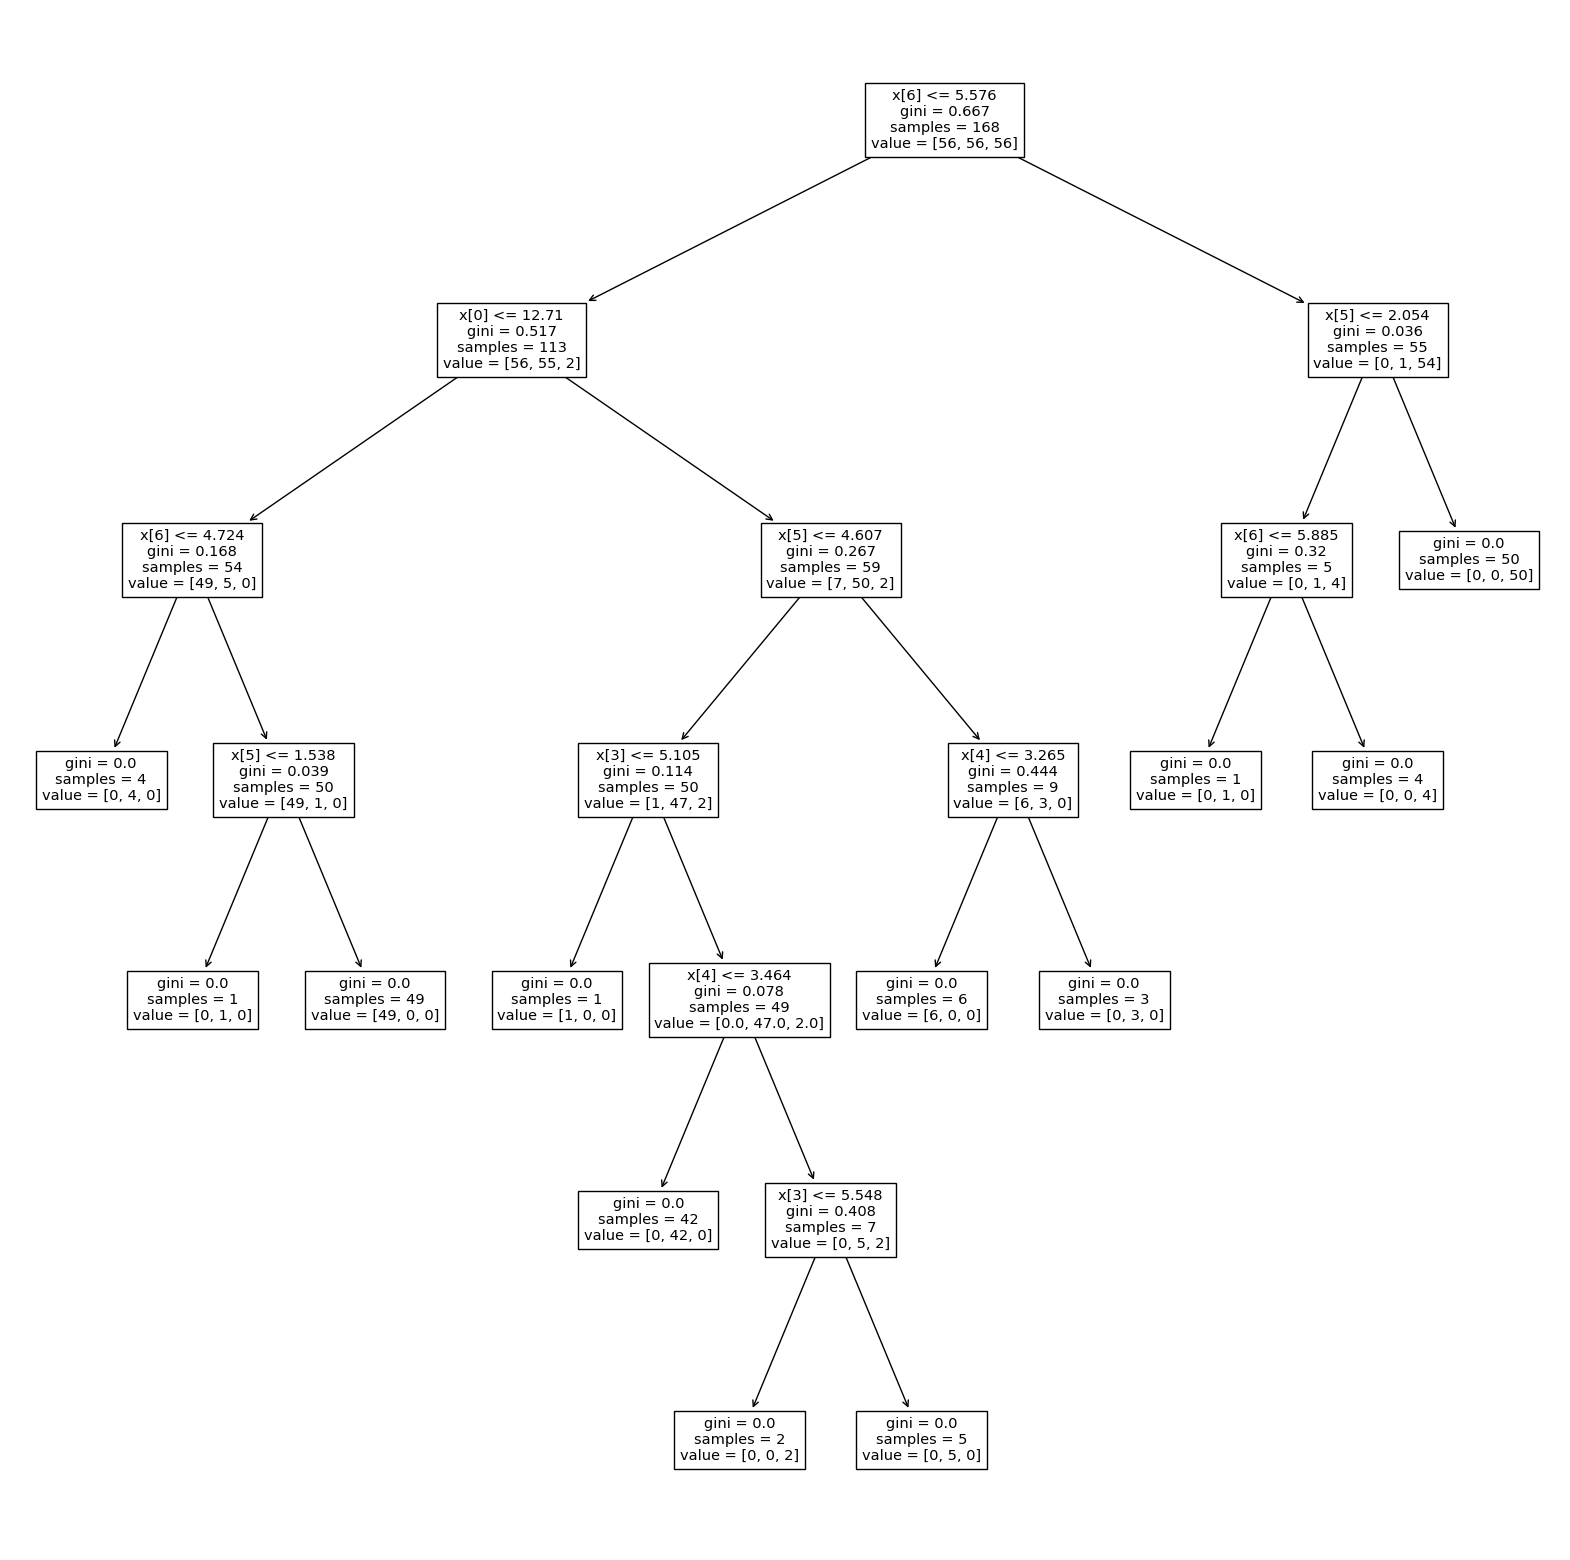

In [12]:
# recupera a melhor árvore
best_tree = trees[1] # neste caso, a árvore avaliada sobre a partição 1

# gera a visualização
plt.figure(figsize=(20,20))
plot_tree(best_tree)
plt.show()

---
## Parte 3: Treinamento sobre outros conjuntos de dados

Nesta etapa, vamos executar o método sobre três diferentes bases de dados presentes na biblioteca _scikit-learn_:
* **moons**: amostras artificiais dispostas em formato de semi círculos sobrepostos;
* **circles**: amostras artificiais dispostas em formato anelar;
* **iris**: famoso conjunto de dados para previsão de espécies da flor íris, com 3 classes [5].

Vamos incialmente visualizar os conjuntos de dados:

------------------------------------------------------------------------------------------


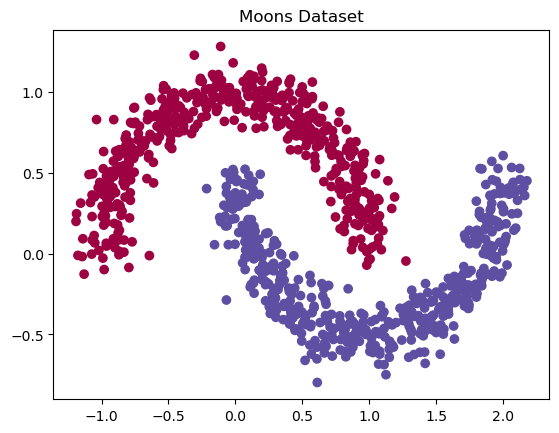

------------------------------------------------------------------------------------------


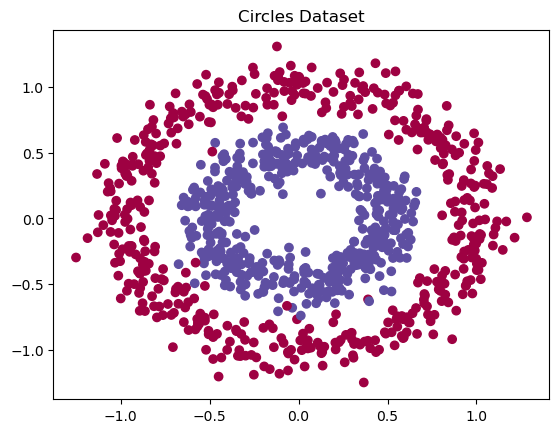

------------------------------------------------------------------------------------------


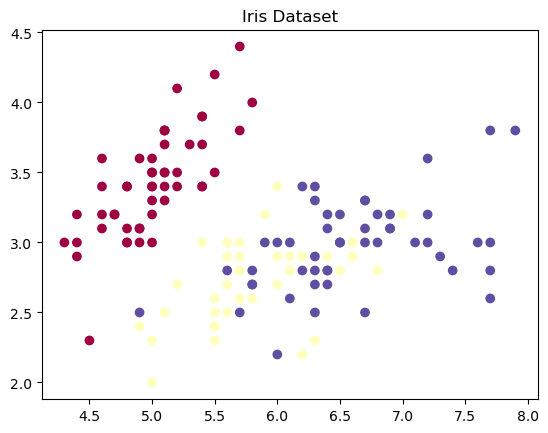

In [13]:
# moons
from sklearn.datasets import make_moons
X_moons, Y_moons = make_moons(n_samples=1000, noise=0.1)
print('---' * 30)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=Y_moons, cmap=plt.cm.Spectral)
plt.title('Moons Dataset')
plt.show()

# circles
from sklearn.datasets import make_circles
X_circles, Y_circles = make_circles(n_samples=1000, noise=0.1, factor=0.5)
print('---' * 30)
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=Y_circles, cmap=plt.cm.Spectral)
plt.title('Circles Dataset')
plt.show()

# iris
from sklearn.datasets import load_iris
iris = load_iris()
X_iris, Y_iris = iris.data[:,:2], iris.target
print('---' * 30)
plt.scatter(X_iris[:, 0], X_iris[:, 1], c=Y_iris, cmap=plt.cm.Spectral)
plt.title('Iris Dataset')
plt.show()

# monta lista de datasets
DATASET_LIST = [
    ('Moons Dataset', X_moons, Y_moons),
    ('Circles Dataset', X_circles, Y_circles),
    ('Iris Dataset', X_iris, Y_iris)
]

Vamos em seguida implementar uma função para execução do modelo sobre as bases de dados. O motivo de fazermos em forma de função é para reaproveitarmos futuramente no notebook.

Iremos implementar três funções.

------------------------------------------------------------------------------------------
Moons Dataset
Acurácia: 1.00


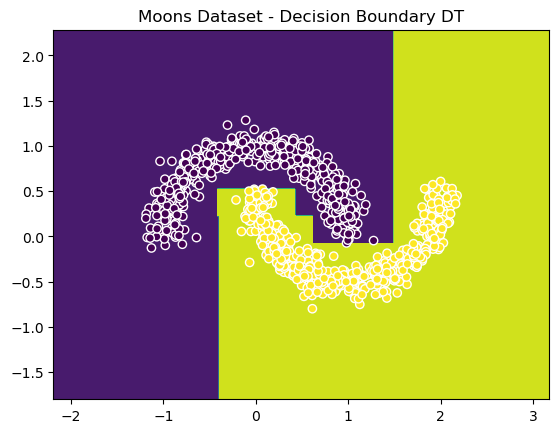

------------------------------------------------------------------------------------------
Circles Dataset
Acurácia: 1.00


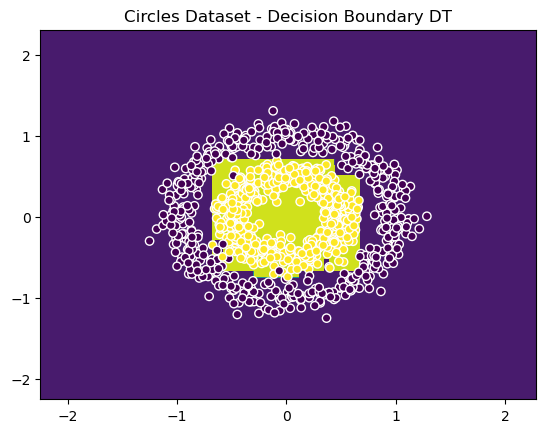

------------------------------------------------------------------------------------------
Iris Dataset
Acurácia: 0.77


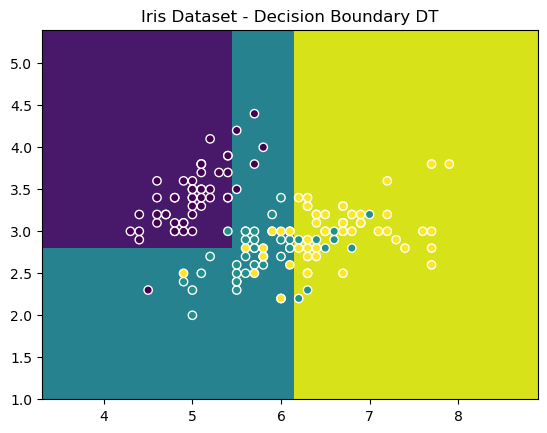

In [14]:
# função para executar o experimento sobre um único dataset
def _run_single_dataset(model, param_dict, X_samples, y_true, dataset_name):
    # realiza a validação cruzada
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)
    
    gscv_model = GridSearchCV(
        estimator=model,
        param_grid=param_dict,
        scoring=make_scorer(accuracy_score),
        cv=cv,
        refit=True # parâmetro usado para retreinar o melhor modelo sobre todo dataset
    )
    
    gscv_model.fit(X_samples, y_true)

    # recupera o melhor modelo e executa sobre a base toda
    best_model = gscv_model.best_estimator_
    y_pred = best_model.predict(X_samples)
    
    # calcula a acurácia
    acc = accuracy_score(y_true, y_pred)
    print("Acurácia: {:.2f}".format(acc))

    # gera o limite de decisão
    display = DecisionBoundaryDisplay.from_estimator(best_model, X_samples, grid_resolution=1000)
    plt.scatter(X_samples[:, 0], X_samples[:, 1], c=y_true, edgecolors='w')
    plt.title("{} - Decision Boundary DT".format(dataset_name))
    plt.show()


# funcao para executar o experimento sobre todos datasets
def run_experiments(Model, param_dict):
    for dataset_name, dataset_X, dataset_Y in DATASET_LIST:
        print('---' * 30)
        print(dataset_name)
        _run_single_dataset(Model, param_dict, dataset_X, dataset_Y, dataset_name)


# execute o experimento
dt_model = DecisionTreeClassifier(random_state=10)
dt_param_dict = {
    'max_depth': [2, 3, 5, 10],
    'criterion': ['entropy', 'gini'],
}
run_experiments(dt_model, dt_param_dict)

---
## Regressão

Finalmente, podemos utilizar também árvores de decisão para problemas de regressão, quando a saída é um número contínuo ao invés de uma classe. 

Vamos construir um conjunto de dados artificial de regressão para o treinamento:

------------------------------------------------------------------------------------------


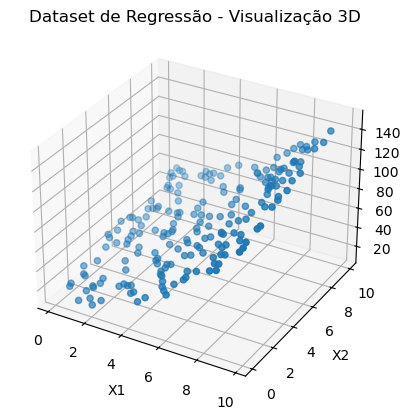

------------------------------------------------------------------------------------------


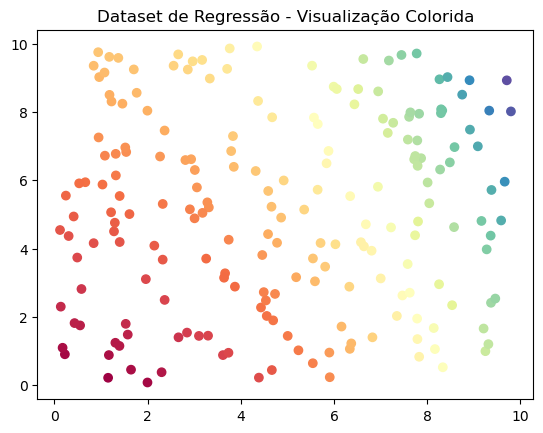

In [15]:
rng = np.random.default_rng(42)
X_reg = rng.random(size=(200, 2)) * 10
Y_reg = X_reg[:, 0]**2 + 5 * X_reg[:, 1] + 10 + rng.normal(loc=0.0, scale=0.1, size=(200,))
X_y = np.concatenate((X_reg, Y_reg.reshape(200, 1)), axis=1)

# Representação 3D
print('---' * 30)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_reg[:, 0], X_reg[:, 1], Y_reg)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Y')
plt.title('Dataset de Regressão - Visualização 3D')
plt.show()

# Representação com espectro de cor
print('---' * 30)
plt.scatter(X_reg[:, 0], X_reg[:, 1], c=Y_reg, cmap=plt.cm.Spectral)
plt.title('Dataset de Regressão - Visualização Colorida')
plt.show()

Em problemas de regressão, os algoritmos de árvore de decisão funcionam de forma bastante parecida com problemas de classificação. Também são gerados cortes, mas relacionados com outras medidas, como erro quadrático ou erro absoluto. O valor das folhas é então definido com base na média entre os valores-alvo das amostras que a compõe.

Vamos construir uma árvore de decisão regressora utilizando o modelo [DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) da biblioteca _scikit-learn_.


Erro Quadrático Médio (RMSE): 195.94



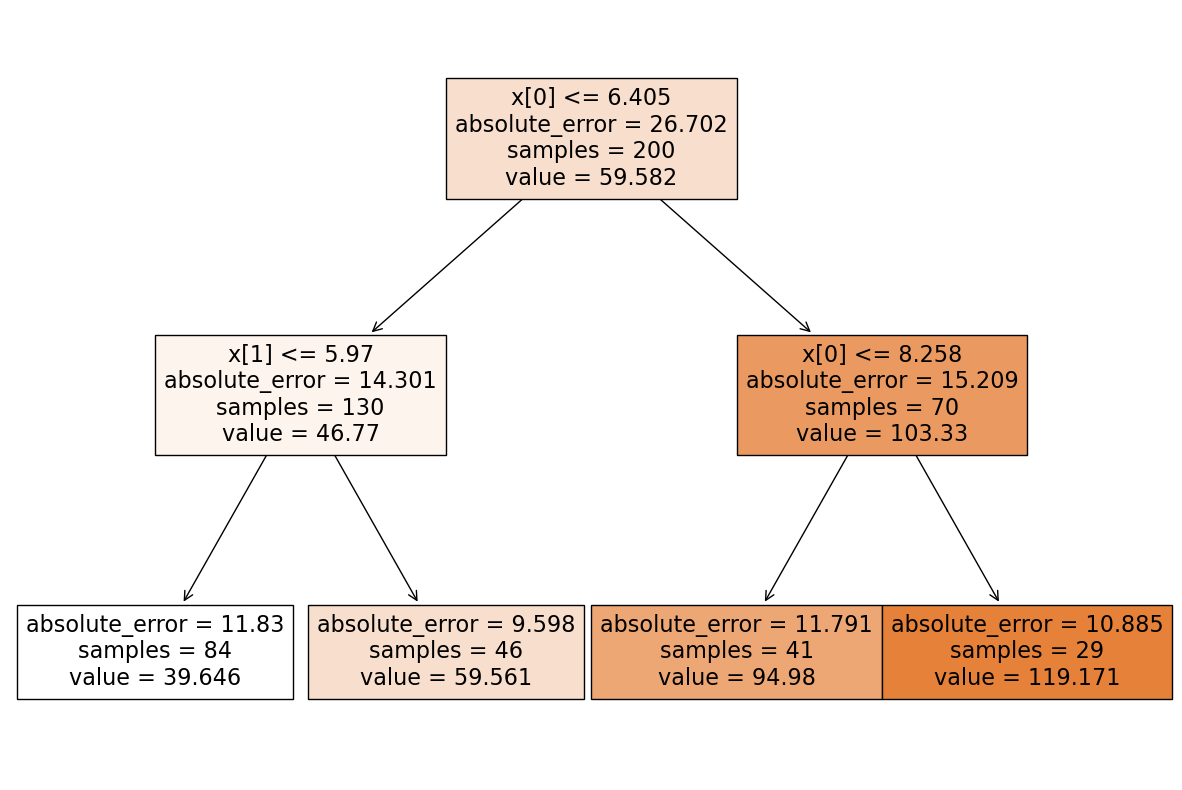

In [16]:
# realiza a validação cruzada
def regression_experiment(model, param_dict):
    cv = KFold(n_splits=5, shuffle=True, random_state=10)
    gscv_model = GridSearchCV(
        estimator=model,
        param_grid=param_dict,
        scoring=make_scorer(mean_squared_error),
        cv=cv,
        refit=True # parâmetro usado para retreinar o melhor modelo sobre todo dataset
    )
    gscv_model.fit(X_reg, Y_reg)
    
    # recupera o melhor modelo e executa sobre a base toda
    best_model = gscv_model.best_estimator_
    y_pred = best_model.predict(X_reg)
    
    # calcula a acurácia
    rmse = mean_squared_error(Y_reg, y_pred)
    print("\nErro Quadrático Médio (RMSE): {:.2f}\n".format(rmse))

    return best_model
    

# executa o experimento
dt_model = DecisionTreeRegressor(random_state=10)
dt_param_dict = {
    'criterion': ['squared_error', 'absolute_error'],
    'max_depth': [2, 3, 5, 10],
}
best_model = regression_experiment(dt_model, dt_param_dict)

# exibe a árvore final
plt.figure(figsize=(15,10))
plot_tree(best_model, filled=True)
plt.show()

---
## Conclusão

Neste notebook, foi apresentado o algoritmo de Árvores de Decisão, tradicional técnica do aprendizado de máquina que tem como principal vantagem a sua explicabilidade. O método opera através da construção de uma árvore, cujos nós correspondem a regras de decisão aprendidas através da análise dos dados e as folhas correspondem ao valor de predição. Foi mostrado como o método pode ser aplicado através da biblioteca _scikit-learn_ para problemas de classificação e regressão.

Espera-se que com o conteúdo deste notebook você esteja apto para resolver problemas através do algoritmo de Árvore de Decisão, extremamente útil e eficiente em problemas com um número baixo de atributos e carência de interpretabilidade.

---
## Referências

[1] J. R. Quinlan. Induction of decision trees. Machine Learning, 1, 81-106 (1986). DOI: [10.1007/BF00116251](https://doi.org/10.1007/BF00116251).

[2] M. Charytanowicz _et al._. Complete Gradient Clustering Algorithm for Features Analysis of X-Ray Images. Information Technologies in Biomedicine, 15-24 ( 201). DOI: [10.1007/978-3-642-13105-9_2](https://doi.org/10.1007/978-3-642-13105-9_2)

---